# Vision Tracker Evaluation — RT-DETR + ByteTrack/Botsort

Runs the RT-DETR model on all vision MOT sequences, compares predictions to GT, 
and reports standard MOT metrics.

**Model:** `solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt`   
**Class:** fish (class_id = 1)  
**Metric matching:** IoU ≥ 0.5

Run from `tracking/` directory.

In [2]:
print("Jupyter OK!")

Jupyter OK!


In [3]:
import sys
sys.path.insert(0, "..")  # make repo root importable

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from tracking.utils.mot_metrics import (
    load_gt, run_inference, img_dir_for, frame_map,
    collect_images,
    compute_metrics, compute_hota, format_summary, build_summary_table,
    plot_metrics_bar, plot_error_breakdown,
    plot_track_comparison, plot_det_timeline, plot_id_switches,
)

plt.rcParams.update({"figure.dpi": 130, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})


/workspace/aquaculture-perception/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────────
REPO        = Path("..").resolve()
VISION_ROOT = REPO / "data-processing" / "vision" / "MOT"
MODEL_PATH  = REPO / "runs/detect/outputs/training/solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt"

# ── Sequence selection ─────────────────────────────────────────────────────────
# List specific sequence names to process, or leave empty to run all.
SELECTED_SEQUENCES = [
    "2024-08-20_14-31-29",
    "2024-08-20_17-02-00",
    "2024-08-20_17-14-36",
    # "2024-08-20_17-39-32",
    "2024-08-20_17-55-40",
    
]

# ── Inference settings ─────────────────────────────────────────────────────────
CONF       = 0.25
IOU_NMS    = 0.45   # NMS threshold for detector
IOU_MATCH  = 0.5    # IoU threshold for GT<->pred matching
DEVICE     = "cuda:0"
FRAME_RATE = 30
TRACKER    = "botsort"   # "bytetrack" | "botsort"

# ── Run identifier (used in filenames and titles) ────────────────────────────
MODEL_NAME = MODEL_PATH.parent.parent.name
RUN_TAG    = f"{MODEL_NAME}+{TRACKER}"

# ── MOT output ────────────────────────────────────────────────────────────────
MOT_OUTPUT_DIR = Path("outputs/inference_annotation_MOT11")
MOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

all_seqs = sorted([p.name for p in VISION_ROOT.iterdir() if p.is_dir()])
SEQUENCES = [s for s in all_seqs if s in SELECTED_SEQUENCES] if SELECTED_SEQUENCES else all_seqs

print(f"Model   : {MODEL_PATH}")
print(f"Device  : {DEVICE}")
print(f"Tracker : {TRACKER}")
print(f"Sequences ({len(SEQUENCES)}):")
for s in SEQUENCES:
    print(f"  {s}")


Model   : /workspace/aquaculture-perception/runs/detect/outputs/training/solaqua_fish_improved_fix/rtdetr_fish_improved_f/weights/best.pt
Device  : cuda:0
Tracker : botsort
Sequences (4):
  2024-08-20_14-31-29
  2024-08-20_17-02-00
  2024-08-20_17-14-36
  2024-08-20_17-55-40


## 1  Run inference on selected sequences
Edit `SELECTED_SEQUENCES` in the cell above to choose which sequences to process.  
Results are cached in memory and saved as MOT .txt files under `outputs/inference_annotation_MOT11/`.  
Re-run this cell to refresh.

In [5]:
gt_dfs   = {}   # {seq_name: gt DataFrame (fish only)}
pred_dfs = {}   # {seq_name: pred DataFrame (fish only)}
total_frames = {}

for seq in SEQUENCES:
    seq_path = VISION_ROOT / seq
    idir     = img_dir_for(seq_path, "vision")

    # Ground truth — fish only (class_id = 1)
    gt = load_gt(seq_path / "gt" / "gt.txt", idir, class_id=1)

    # Inference
    pred = run_inference(MODEL_PATH, idir,
                         conf=CONF, iou=IOU_NMS,
                         device=DEVICE, frame_rate=FRAME_RATE,
                         tracker_type=TRACKER,
                         desc=seq)
    pred_fish = pred[pred["class_id"] == 1].copy()

    gt_dfs[seq]   = gt
    pred_dfs[seq] = pred_fish
    total_frames[seq] = len(list(idir.glob("*.jpg")))

    # ── Write MOT .txt (same format as tracking-inference_improved_MOT11.py) ──
    mot_lines = [
        f"{int(row.frame_id)},{int(row.track_id)},"
        f"{row.x:.2f},{row.y:.2f},{row.w:.2f},{row.h:.2f},"
        f"1,{int(row.class_id)},1.000000"
        for row in pred_fish.sort_values(["frame_id", "track_id"]).itertuples()
    ]
    mot_path = MOT_OUTPUT_DIR / f"INFERENCE_MOT11_{seq}_{RUN_TAG}.txt"
    mot_path.write_text("\n".join(mot_lines), encoding="utf-8")

    print(f"{seq}: GT={len(gt)} annots, Pred={len(pred_fish)} annots  "
          f"-> {mot_path.name}")


2024-08-20_14-31-29: 100%|██████████| 1500/1500 [01:26<00:00, 17.25it/s]


2024-08-20_14-31-29: GT=4967 annots, Pred=4569 annots  -> INFERENCE_MOT11_2024-08-20_14-31-29_rtdetr_fish_improved_f+botsort.txt


2024-08-20_17-02-00: 100%|██████████| 1212/1212 [01:19<00:00, 15.28it/s]


2024-08-20_17-02-00: GT=1104 annots, Pred=1076 annots  -> INFERENCE_MOT11_2024-08-20_17-02-00_rtdetr_fish_improved_f+botsort.txt


2024-08-20_17-14-36: 100%|██████████| 834/834 [00:54<00:00, 15.29it/s]


2024-08-20_17-14-36: GT=899 annots, Pred=875 annots  -> INFERENCE_MOT11_2024-08-20_17-14-36_rtdetr_fish_improved_f+botsort.txt


2024-08-20_17-55-40: 100%|██████████| 796/796 [00:46<00:00, 17.19it/s]

2024-08-20_17-55-40: GT=1667 annots, Pred=1459 annots  -> INFERENCE_MOT11_2024-08-20_17-55-40_rtdetr_fish_improved_f+botsort.txt


## 2  Compute metrics

In [6]:
accs    = {}
results = {}

for seq in SEQUENCES:
    acc, summary = compute_metrics(gt_dfs[seq], pred_dfs[seq], iou_threshold=IOU_MATCH)
    hota         = compute_hota(gt_dfs[seq], pred_dfs[seq])
    for k, v in hota.items():
        summary[k] = v

    accs[seq]    = acc
    results[seq] = summary
    print(f"{seq[-8:]}  "
          f"HOTA={hota['hota']*100:.1f}%  "
          f"MOTA={float(summary['mota'].iloc[0])*100:.1f}%  "
          f"IDF1={float(summary['idf1'].iloc[0])*100:.1f}%  "
          f"MOTP={float(summary['motp'].iloc[0])*100:.1f}%  "
          f"IDSW={int(summary['num_switches'].iloc[0])}")

print()
print(f"\nRun: {RUN_TAG}")
display(build_summary_table(results))

14-31-29  HOTA=83.0%  MOTA=89.7%  IDF1=89.2%  MOTP=6.6%  IDSW=12
17-02-00  HOTA=96.1%  MOTA=95.7%  IDF1=97.8%  MOTP=2.1%  IDSW=0
17-14-36  HOTA=91.9%  MOTA=89.7%  IDF1=94.5%  MOTP=2.8%  IDSW=1
17-55-40  HOTA=76.5%  MOTA=79.3%  IDF1=82.8%  MOTP=7.5%  IDSW=15


Run: rtdetr_fish_improved_f+botsort


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,83.0%,77.6%,92.8%,89.7%,89.2%,6.6%,91.0%,98.9%,51,449,12,42,0,53
1,17-02-00,96.1%,92.5%,100.0%,95.7%,97.8%,2.1%,96.6%,99.1%,10,38,0,21,1,22
2,17-14-36,91.9%,85.4%,99.4%,89.7%,94.5%,2.8%,93.5%,96.1%,34,58,1,23,2,30
3,17-55-40,76.5%,69.2%,87.2%,79.3%,82.8%,7.5%,83.9%,95.8%,61,269,15,42,2,65


## 3  Metrics bar charts

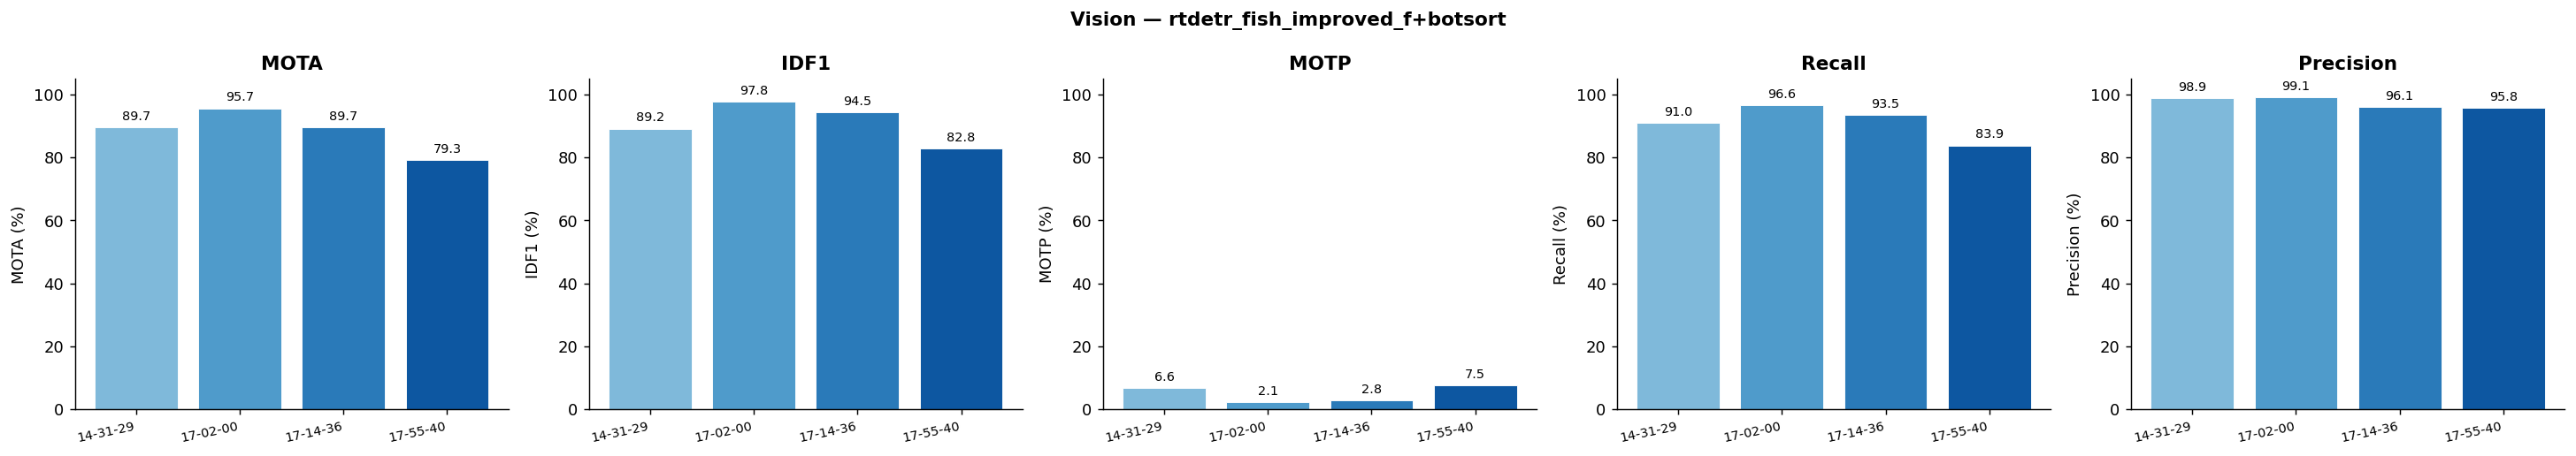

In [7]:
fig = plot_metrics_bar(results, metrics=("MOTA", "IDF1", "MOTP", "Recall", "Precision"),
                       title=f"Vision — {RUN_TAG}")
plt.savefig(f"outputs/vision_{RUN_TAG}_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## 4  Error breakdown — FP / FN / ID switches

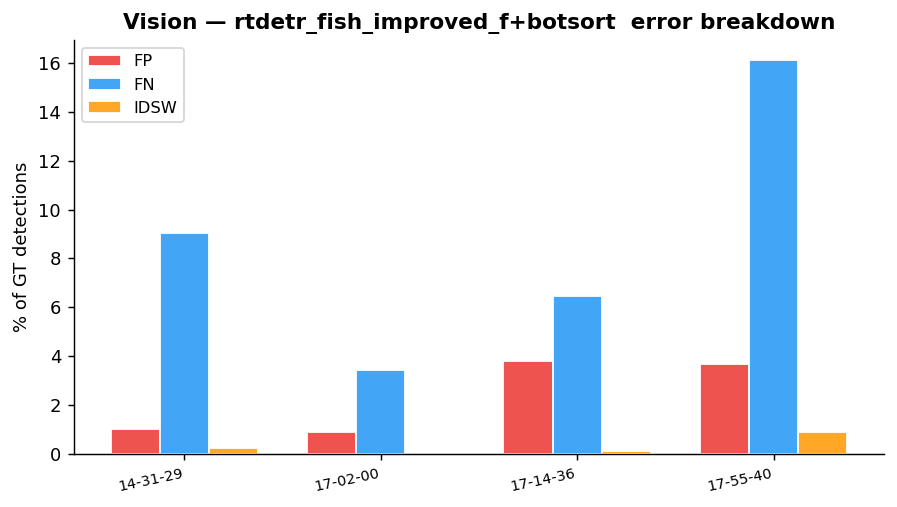

In [8]:
fig = plot_error_breakdown(results, title=f"Vision — {RUN_TAG}  error breakdown")
plt.savefig(f"outputs/vision_{RUN_TAG}_error_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 5  GT vs predicted track count

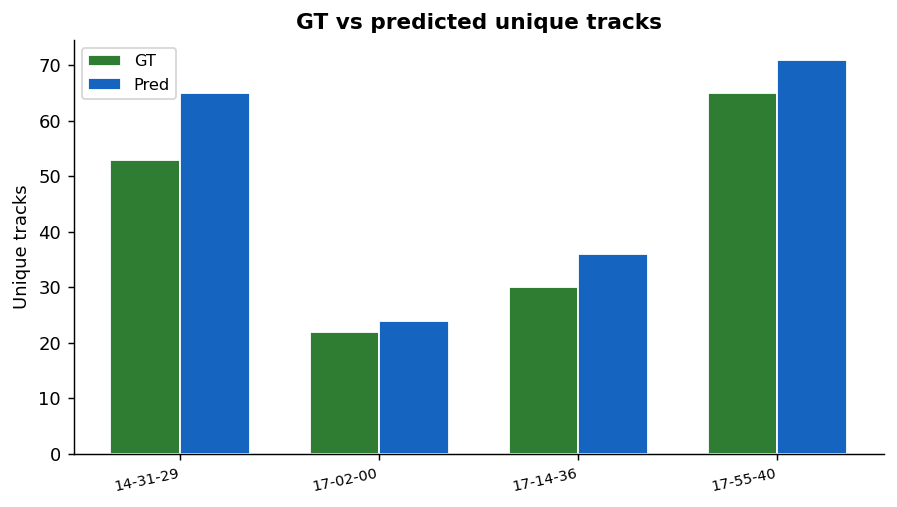

In [9]:
fig = plot_track_comparison(gt_dfs, pred_dfs)
plt.savefig(f"outputs/vision_{RUN_TAG}_track_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6  Detection count per frame — GT vs predicted

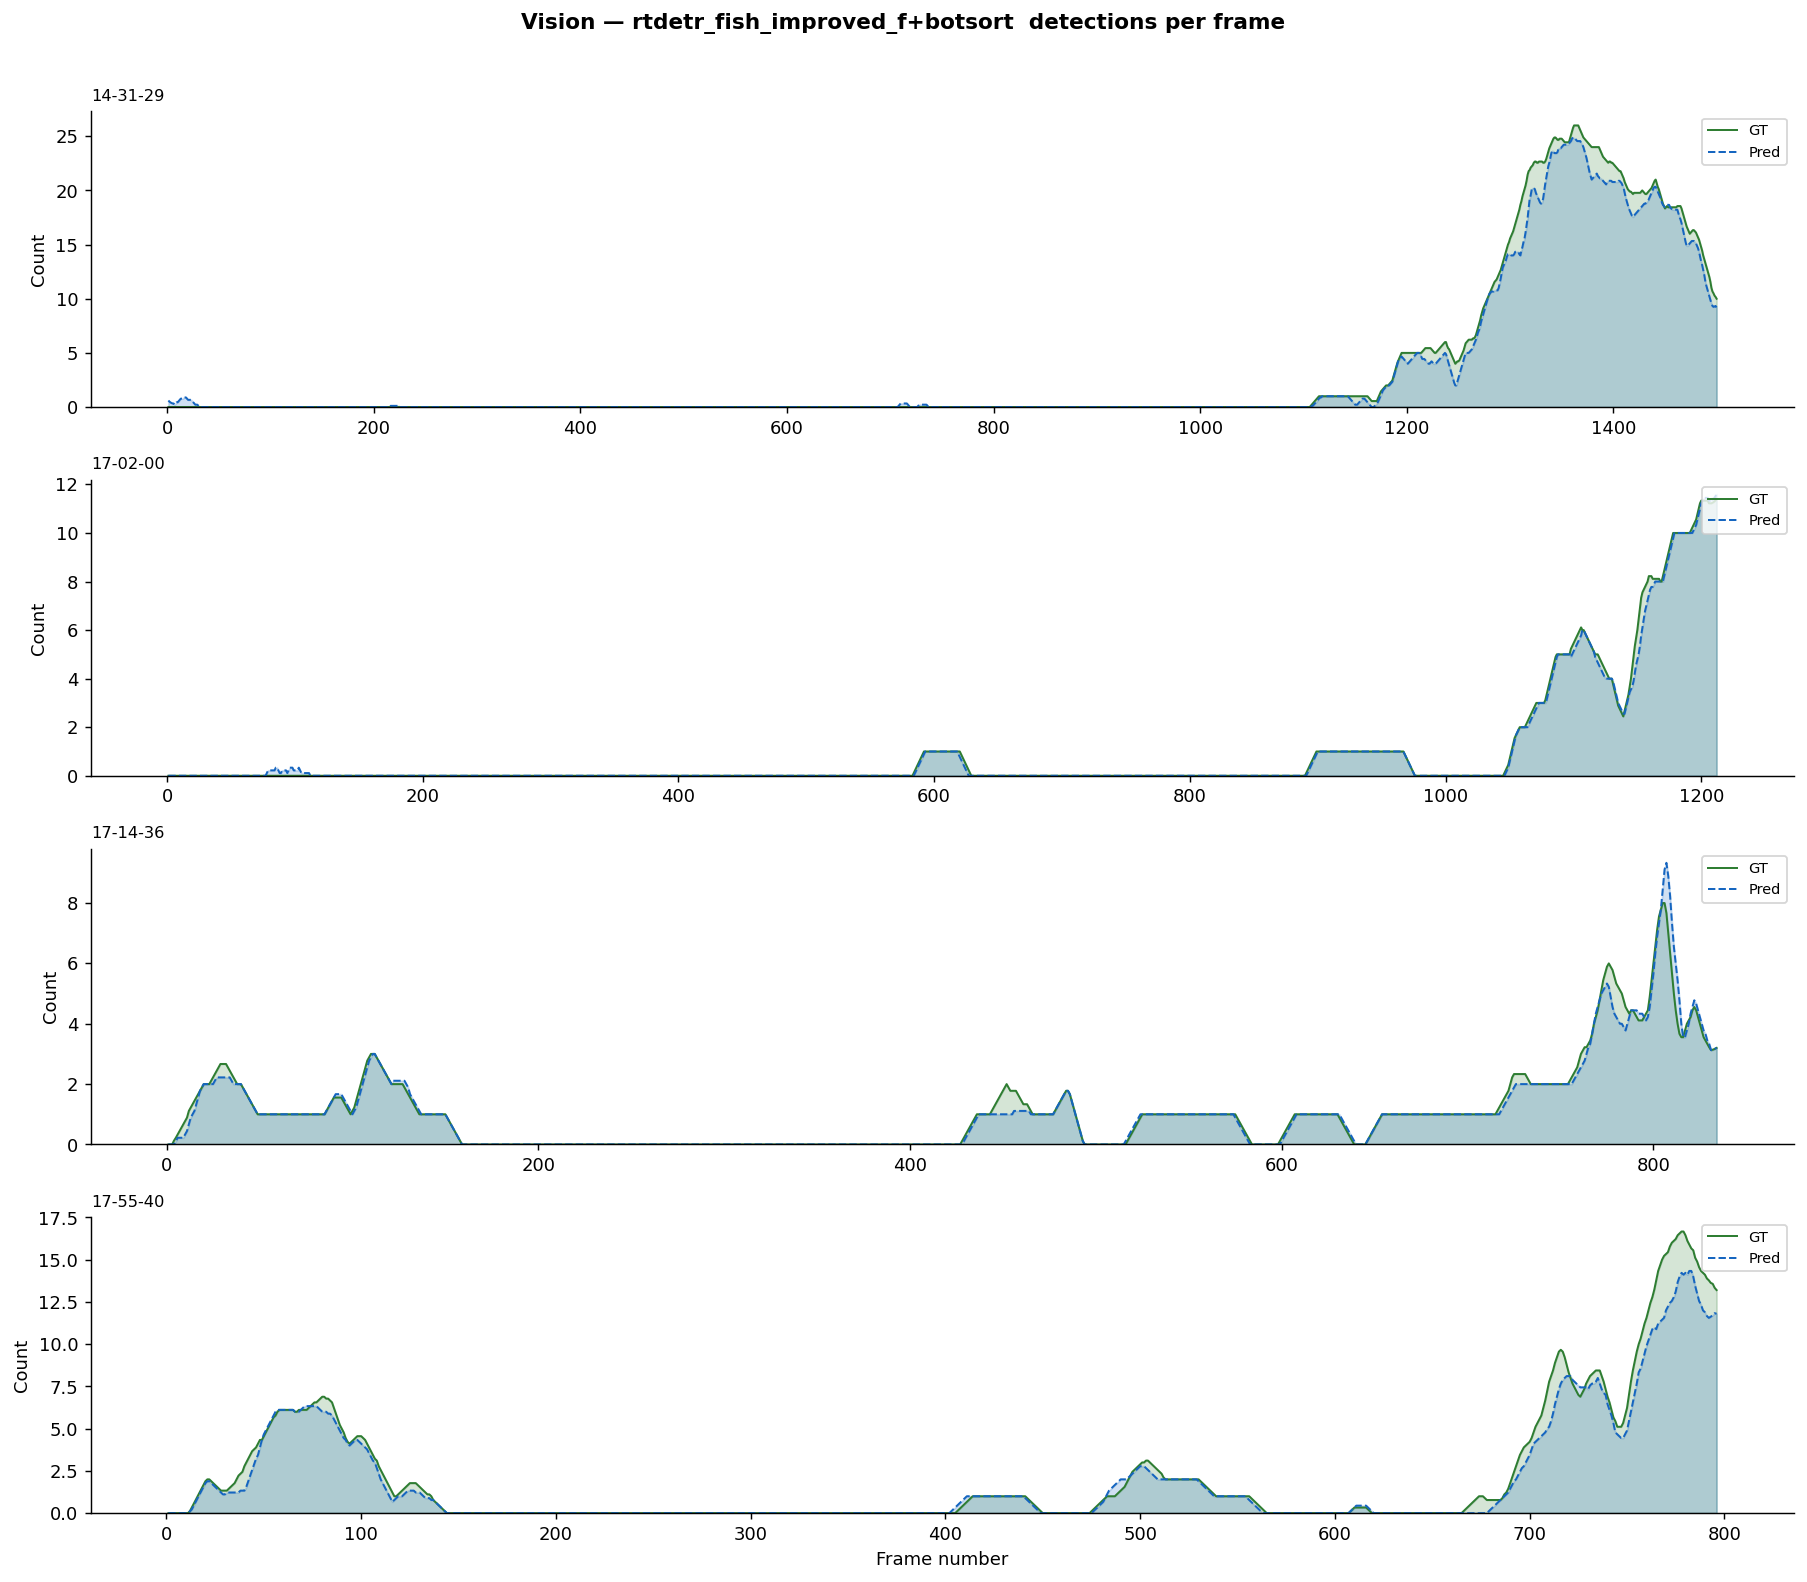

In [10]:
fig = plot_det_timeline(gt_dfs, pred_dfs, total_frames,
                        title=f"Vision — {RUN_TAG}  detections per frame")
plt.savefig(f"outputs/vision_{RUN_TAG}_det_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 7  Cumulative ID switches over time

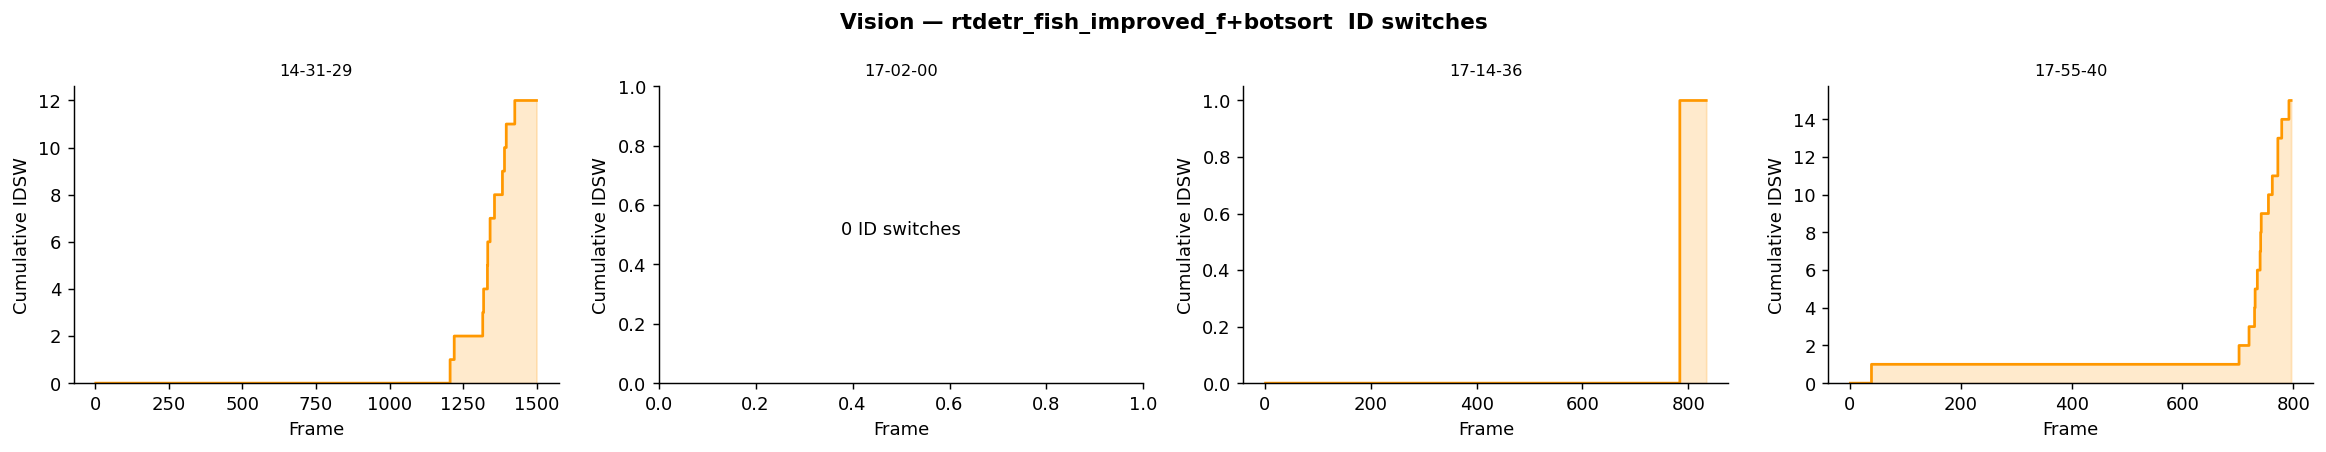

In [11]:
fig = plot_id_switches(accs, total_frames,
                       title=f"Vision — {RUN_TAG}  ID switches")
plt.savefig(f"outputs/vision_{RUN_TAG}_id_switches.png", dpi=150, bbox_inches="tight")
plt.show()

## 8  MT / PT / ML breakdown
Mostly Tracked (>80% life covered), Partially Tracked, Mostly Lost (<20%).

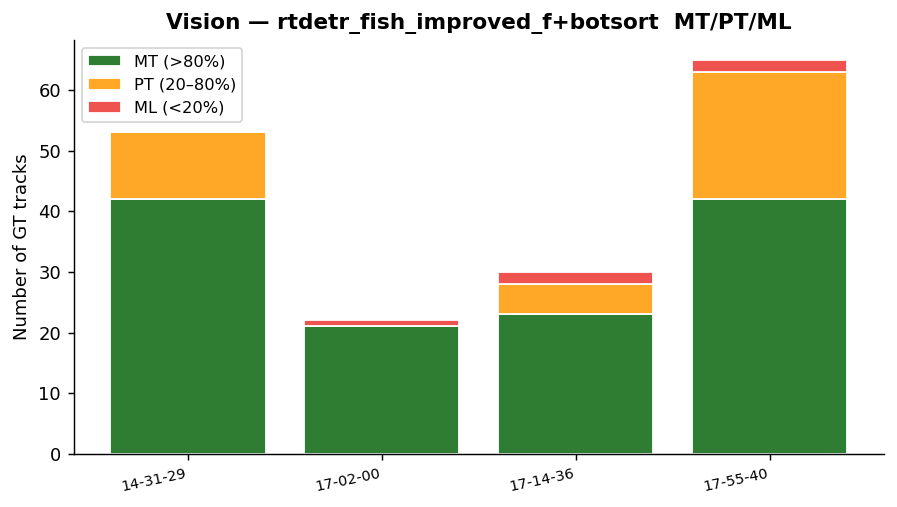

In [12]:
seq_names = list(results.keys())
mt_vals = [int(results[s]["mostly_tracked"].iloc[0])   for s in seq_names]
pt_vals = [int(results[s]["partially_tracked"].iloc[0]) for s in seq_names]
ml_vals = [int(results[s]["mostly_lost"].iloc[0])       for s in seq_names]

x = np.arange(len(seq_names))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x, mt_vals, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
ax.bar(x, pt_vals, bottom=mt_vals, label="PT (20–80%)", color="#FFA726", edgecolor="white")
ax.bar(x, ml_vals, bottom=[m+p for m,p in zip(mt_vals,pt_vals)],
       label="ML (<20%)", color="#EF5350", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([s[-8:] for s in seq_names], rotation=12, ha="right", fontsize=8)
ax.set_ylabel("Number of GT tracks")
ax.set_title(f"Vision — {RUN_TAG}  MT/PT/ML", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"outputs/vision_{RUN_TAG}_mt_pt_ml.png", dpi=150, bbox_inches="tight")
plt.show()

## V1  Track + trail visualization
Shows bounding boxes and track IDs for one frame, plus the trajectory
of each track as a line over the last `TRAIL_FRAMES` frames.
Edit `VIZ_SEQ`, `VIZ_FRAME_NORM`, and `TRAIL_FRAMES` to configure.

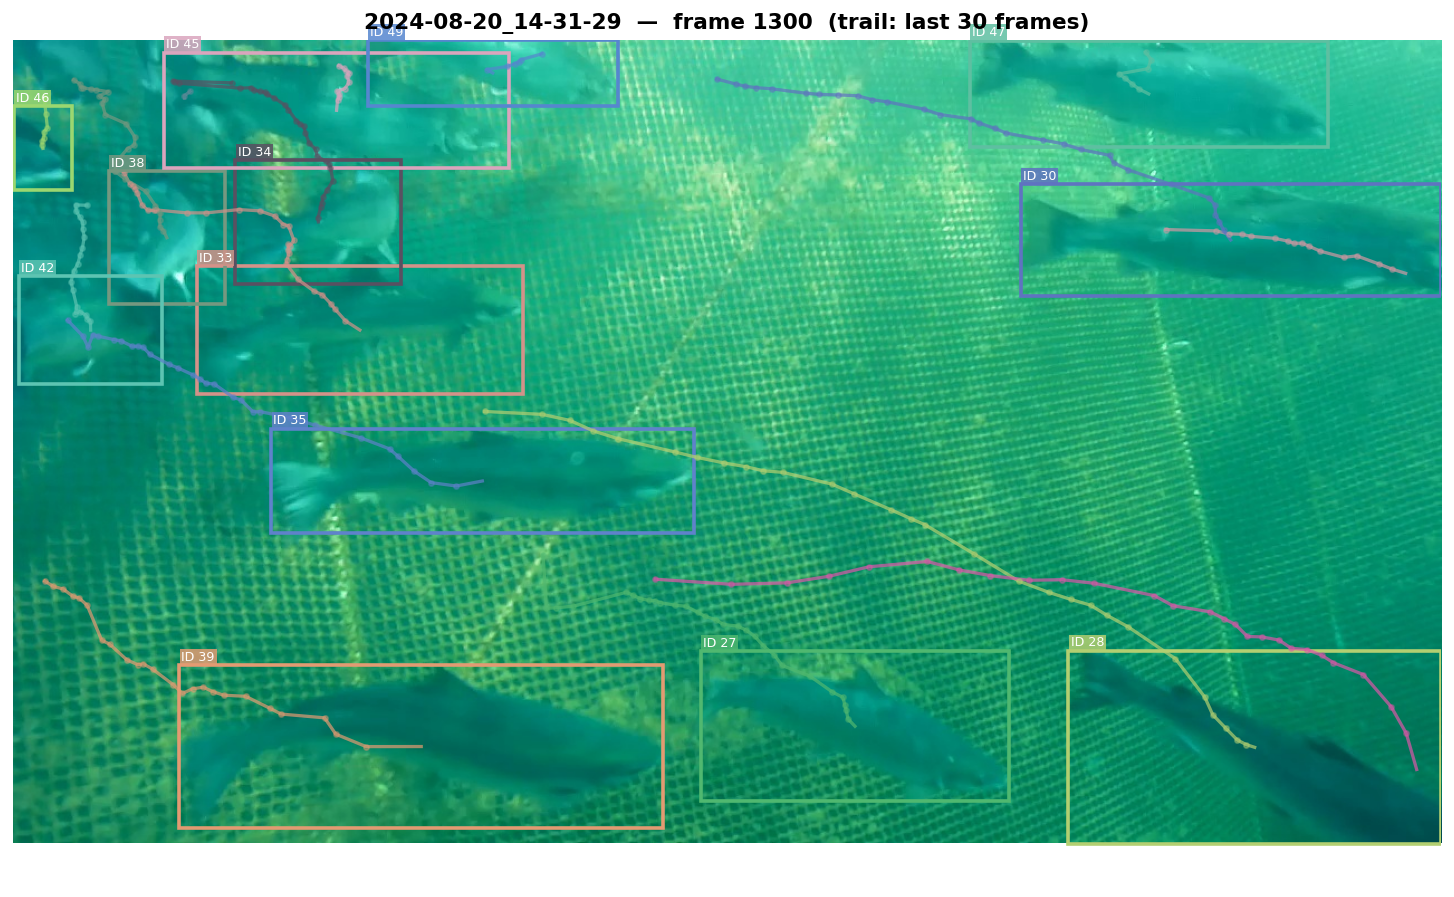

In [13]:
# ── Config ────────────────────────────────────────────────────────────────────
VIZ_SEQ        = SEQUENCES[0]   # sequence name
VIZ_FRAME_NORM = 1300             # frame to highlight (1-indexed sequential)
TRAIL_FRAMES   = 30             # how many past frames to draw as trail

# ── Load image ────────────────────────────────────────────────────────────────
idir      = img_dir_for(VISION_ROOT / VIZ_SEQ, "vision")
fn_to_img = {i + 1: p for i, p in enumerate(collect_images(idir))}

assert VIZ_FRAME_NORM in fn_to_img, f"Frame {VIZ_FRAME_NORM} not found in sequence"
img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img[VIZ_FRAME_NORM])), cv2.COLOR_BGR2RGB)

pred = pred_dfs[VIZ_SEQ]

# ── Per-track color (seeded by track id) ──────────────────────────────────────
def track_color(tid):
    rng = np.random.default_rng(seed=int(tid))
    return tuple(rng.integers(80, 230, size=3) / 255)

# ── Collect trails ────────────────────────────────────────────────────────────
trail_start = max(1, VIZ_FRAME_NORM - TRAIL_FRAMES + 1)
trail_df    = pred[(pred["frame_norm"] >= trail_start) &
                   (pred["frame_norm"] <= VIZ_FRAME_NORM)].copy()
trail_df["cx"] = trail_df["x"] + trail_df["w"] / 2
trail_df["cy"] = trail_df["y"] + trail_df["h"] / 2

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(img_rgb)

# Draw trail lines
for tid, grp in trail_df.groupby("track_id"):
    grp = grp.sort_values("frame_norm")
    if len(grp) < 2:
        continue
    # Fade: older points more transparent
    c = track_color(tid)
    ax.plot(grp["cx"], grp["cy"], "-", color=c, lw=1.8, alpha=0.7)
    ax.scatter(grp["cx"].iloc[:-1], grp["cy"].iloc[:-1],
               s=8, color=c, alpha=0.4, zorder=3)

# Draw BBs + ID labels for the target frame
for _, row in pred[pred["frame_norm"] == VIZ_FRAME_NORM].iterrows():
    tid = int(row.track_id)
    c   = track_color(tid)
    ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                               linewidth=2, edgecolor=c, facecolor="none"))
    ax.text(row.x + 2, row.y - 4, f"ID {tid}", fontsize=7, color="white",
            bbox=dict(facecolor=c, alpha=0.85, pad=1, edgecolor="none"))

ax.set_title(f"{VIZ_SEQ}  —  frame {VIZ_FRAME_NORM}  "
             f"(trail: last {TRAIL_FRAMES} frames)", fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/vision_trail_viz.png", dpi=150, bbox_inches="tight")
plt.show()


## V2  GT vs inference frame comparison
Green = ground truth boxes, red = predicted boxes.

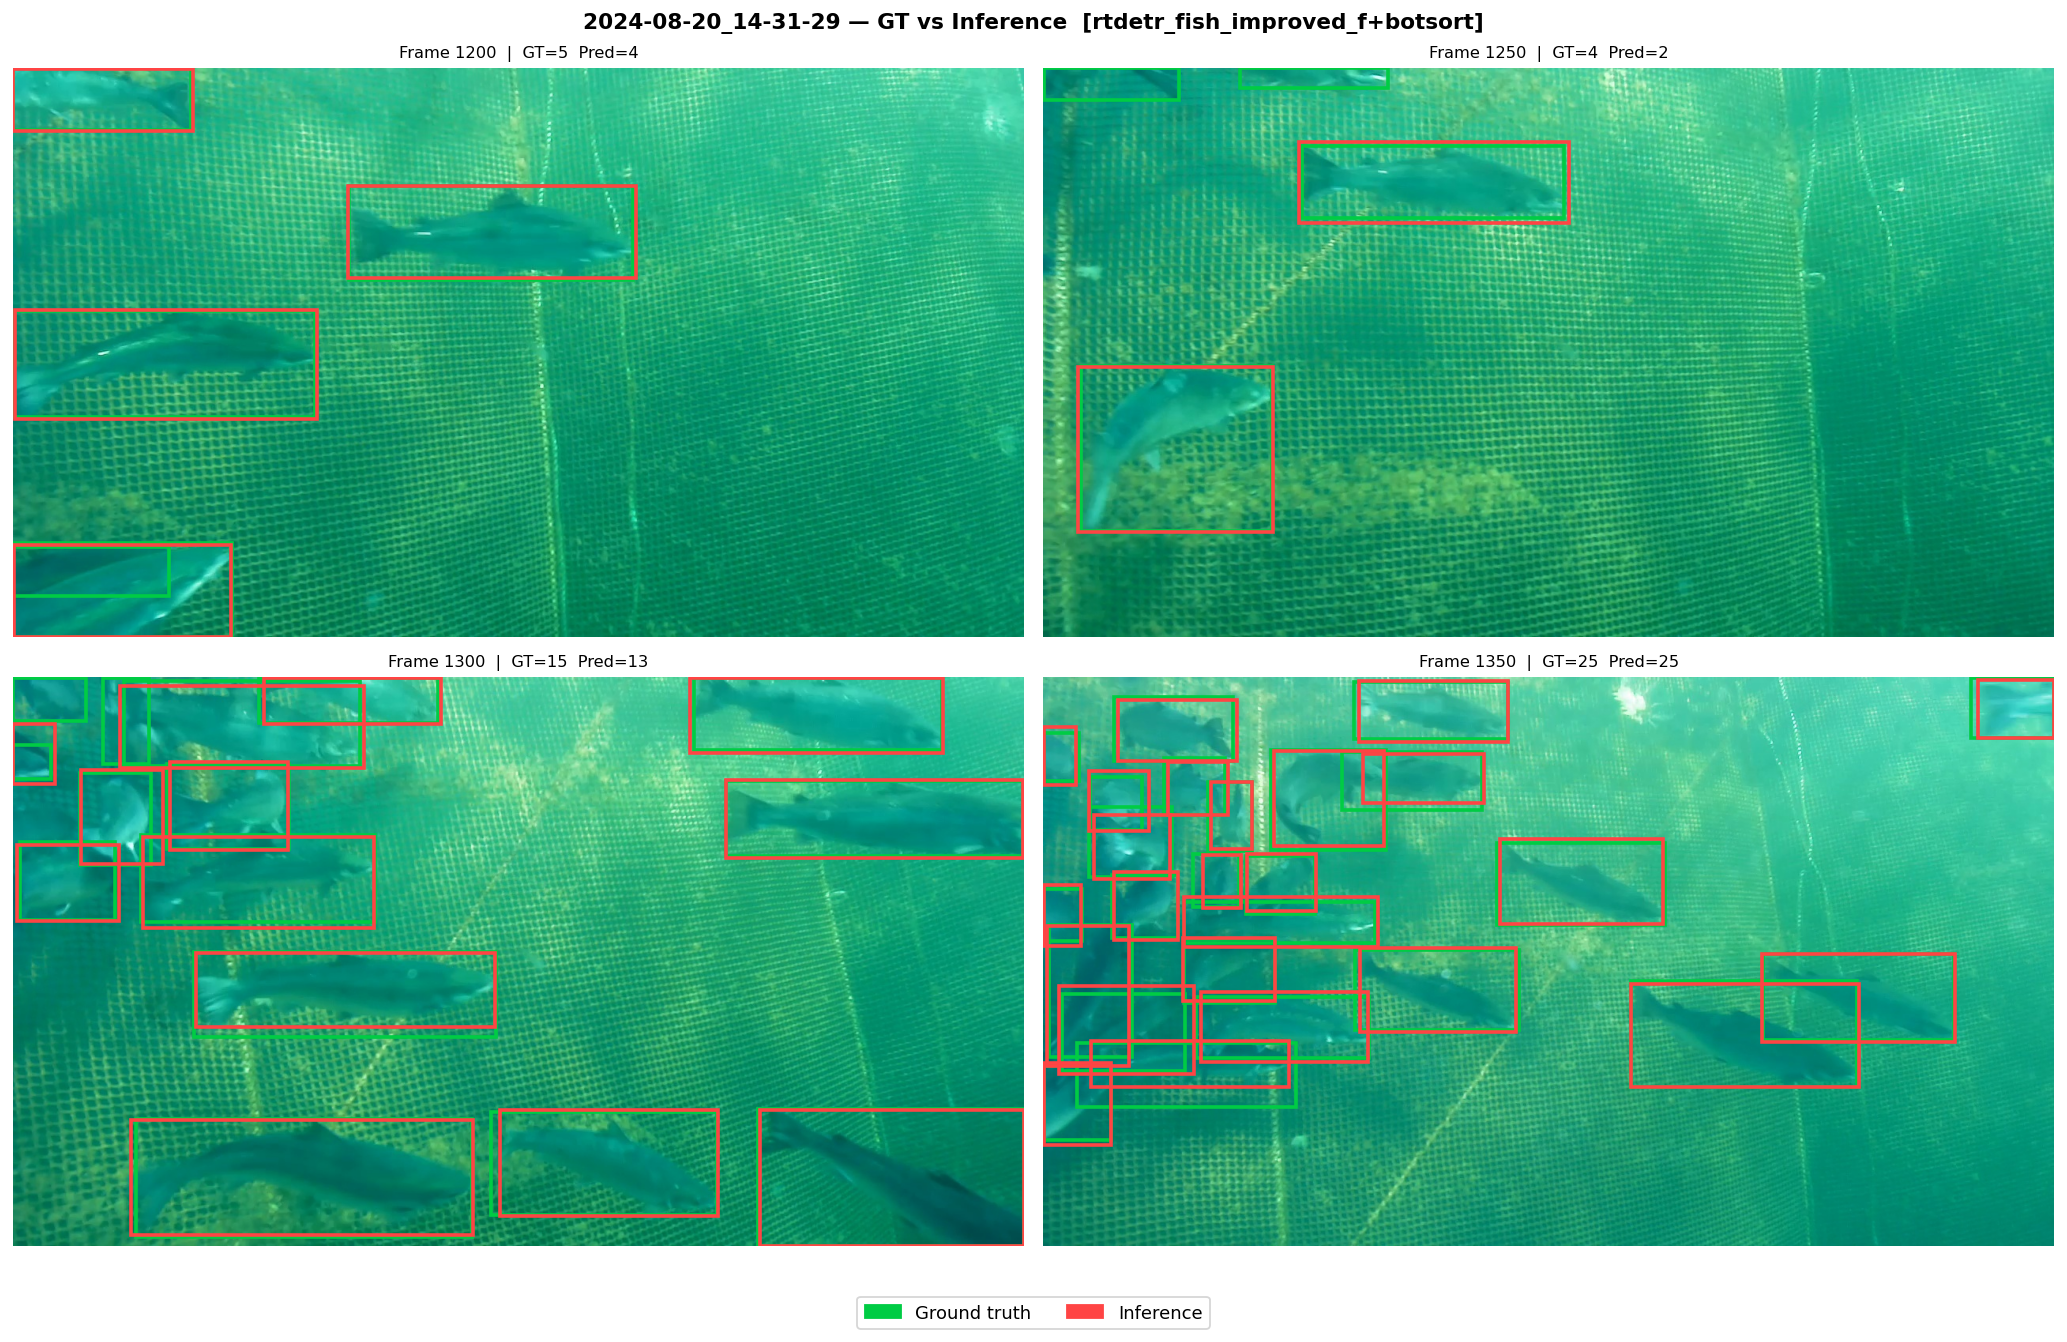

In [14]:
# ── Config ────────────────────────────────────────────────────────────────────
COMPARE_SEQ    = SEQUENCES[0]
COMPARE_FRAMES = [1200, 1250, 1300, 1350]   # frame_norm indices (1-indexed sequential)
NCOLS          = 2

GT_COLOR   = "#00CC44"   # green
PRED_COLOR = "#FF4444"   # red

# ── Plot ──────────────────────────────────────────────────────────────────────
idir_c      = img_dir_for(VISION_ROOT / COMPARE_SEQ, "vision")
fn_to_img_c = {i + 1: p for i, p in enumerate(collect_images(idir_c))}
gt_c        = gt_dfs[COMPARE_SEQ]
pred_c      = pred_dfs[COMPARE_SEQ]

valid_frames = [fn for fn in COMPARE_FRAMES if fn in fn_to_img_c]
nrows = (len(valid_frames) + NCOLS - 1) // NCOLS
fig, axes = plt.subplots(nrows, NCOLS, figsize=(NCOLS * 8, nrows * 5))
axes = np.array(axes).flatten()

for i, fn in enumerate(valid_frames):
    ax = axes[i]
    img_rgb = cv2.cvtColor(cv2.imread(str(fn_to_img_c[fn])), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    for _, row in gt_c[gt_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=GT_COLOR, facecolor="none"))

    for _, row in pred_c[pred_c["frame_norm"] == fn].iterrows():
        ax.add_patch(plt.Rectangle((row.x, row.y), row.w, row.h,
                                   linewidth=2, edgecolor=PRED_COLOR, facecolor="none"))

    n_gt   = (gt_c["frame_norm"]   == fn).sum()
    n_pred = (pred_c["frame_norm"] == fn).sum()
    ax.set_title(f"Frame {fn}  |  GT={n_gt}  Pred={n_pred}", fontsize=9)
    ax.axis("off")

for j in range(len(valid_frames), len(axes)):
    axes[j].set_visible(False)

fig.legend(
    handles=[
        mpatches.Patch(color=GT_COLOR,   label="Ground truth"),
        mpatches.Patch(color=PRED_COLOR, label="Inference"),
    ],
    loc="lower center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04),
)
fig.suptitle(f"{COMPARE_SEQ} — GT vs Inference  [{RUN_TAG}]", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"outputs/vision_{RUN_TAG}_gt_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()



## Combined — all sequences
Aggregates all selected sequences into a single evaluation.
Frame and track IDs are offset per sequence to avoid collisions.

Combined (4 seq)  HOTA=84.5%  MOTA=88.4%  IDF1=89.7%  IDSW=28

Run: rtdetr_fish_improved_f+botsort


,Sequence,HOTA,DetA,AssA,MOTA,IDF1,MOTP,Recall,Precision,FP,FN,IDSW,MT,ML,GT tracks
0,14-31-29,83.0%,77.6%,92.8%,89.7%,89.2%,6.6%,91.0%,98.9%,51,449,12,42,0,53
1,17-02-00,96.1%,92.5%,100.0%,95.7%,97.8%,2.1%,96.6%,99.1%,10,38,0,21,1,22
2,17-14-36,91.9%,85.4%,99.4%,89.7%,94.5%,2.8%,93.5%,96.1%,34,58,1,23,2,30
3,17-55-40,76.5%,69.2%,87.2%,79.3%,82.8%,7.5%,83.9%,95.8%,61,269,15,42,2,65
4,COMBINED,84.5%,78.3%,93.6%,88.4%,89.7%,5.7%,90.6%,98.0%,156,814,28,128,5,170


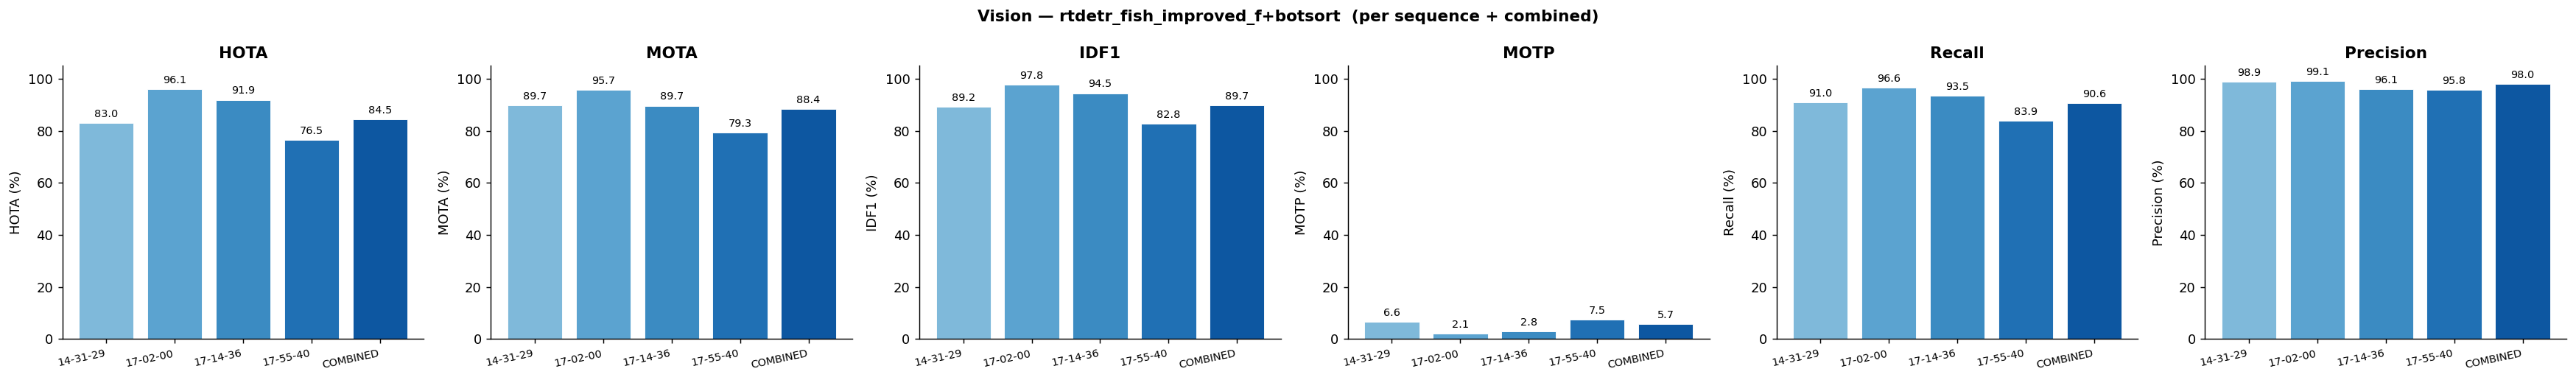

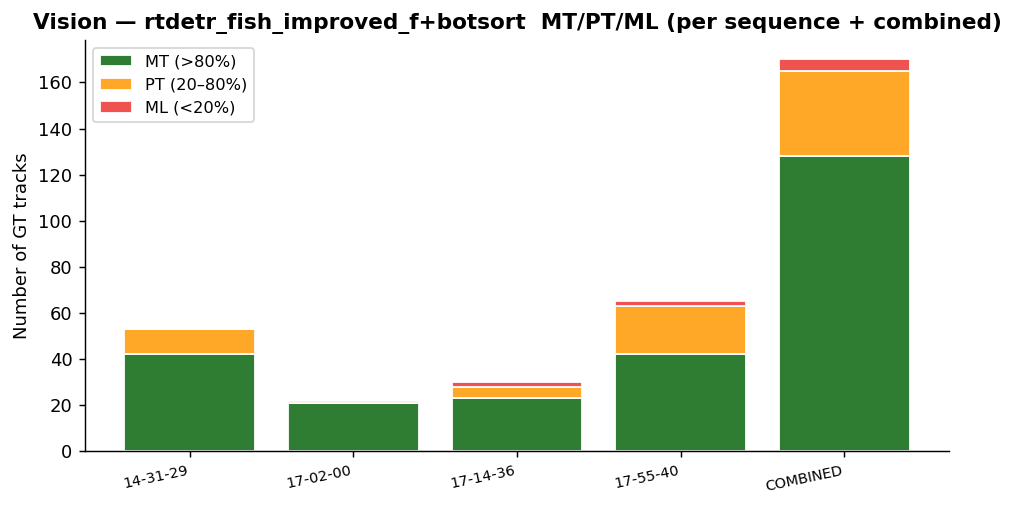

In [15]:
# ── Stack all sequences (offset frame/track IDs per sequence) ─────────────────
_OFF = 10_000
gt_combined   = pd.concat(
    [gt_dfs[s].assign(frame_norm=gt_dfs[s]["frame_norm"] + i * _OFF,
                      track_id  =gt_dfs[s]["track_id"]   + i * _OFF)
     for i, s in enumerate(SEQUENCES)],
    ignore_index=True,
)
pred_combined = pd.concat(
    [pred_dfs[s].assign(frame_norm=pred_dfs[s]["frame_norm"] + i * _OFF,
                        track_id  =pred_dfs[s]["track_id"]   + i * _OFF)
     for i, s in enumerate(SEQUENCES)],
    ignore_index=True,
)

# ── Compute combined metrics ───────────────────────────────────────────────────
_, summ_comb = compute_metrics(gt_combined, pred_combined, iou_threshold=IOU_MATCH)
hota_comb    = compute_hota(gt_combined, pred_combined)
for k, v in hota_comb.items():
    summ_comb[k] = v

print(f"Combined ({len(SEQUENCES)} seq)  "
      f"HOTA={hota_comb['hota']*100:.1f}%  "
      f"MOTA={float(summ_comb['mota'].iloc[0])*100:.1f}%  "
      f"IDF1={float(summ_comb['idf1'].iloc[0])*100:.1f}%  "
      f"IDSW={int(summ_comb['num_switches'].iloc[0])}")

# ── Table: per-sequence rows + COMBINED row ────────────────────────────────────
results_all = dict(results) | {"COMBINED": summ_comb}
print(f"\nRun: {RUN_TAG}")
display(build_summary_table(results_all))

# ── Metrics bar chart ──────────────────────────────────────────────────────────
fig = plot_metrics_bar(
    results_all,
    metrics=("HOTA", "MOTA", "IDF1", "MOTP", "Recall", "Precision"),
    title=f"Vision — {RUN_TAG}  (per sequence + combined)",
)
plt.savefig(f"outputs/vision_{RUN_TAG}_combined_metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# ── MT / PT / ML ───────────────────────────────────────────────────────────────
_seq_all = list(results_all.keys())
_mt = [int(results_all[s]["mostly_tracked"].iloc[0])   for s in _seq_all]
_pt = [int(results_all[s]["partially_tracked"].iloc[0]) for s in _seq_all]
_ml = [int(results_all[s]["mostly_lost"].iloc[0])       for s in _seq_all]

x = np.arange(len(_seq_all))
fig, ax = plt.subplots(figsize=(max(7, len(_seq_all) * 1.5), 4))
ax.bar(x, _mt, label="MT (>80%)",  color="#2E7D32", edgecolor="white")
ax.bar(x, _pt, bottom=_mt, label="PT (20–80%)", color="#FFA726", edgecolor="white")
ax.bar(x, _ml, bottom=[m + p for m, p in zip(_mt, _pt)],
       label="ML (<20%)", color="#EF5350", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([s[-8:] for s in _seq_all], rotation=12, ha="right", fontsize=8)
ax.set_ylabel("Number of GT tracks")
ax.set_title(f"Vision — {RUN_TAG}  MT/PT/ML (per sequence + combined)", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"outputs/vision_{RUN_TAG}_combined_mt_pt_ml.png", dpi=150, bbox_inches="tight")
plt.show()
